# Tidyverse Packages

- GGplot
- Lubridate
- Forcats 
- Purrr

In [3]:
library(tidyverse)

In [11]:
#options
setwd('/home/ikakke/Vault/citadel/learning-data-with-lara/Learniing R')

In [12]:
#import dataset
nhanes <- read_csv("data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome, HomeOwn, Work, BMICat...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Length, HeadCirc, Height, BM...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
Removed 2258 rows containing non-finite outside the scale range (`stat_boxplot()`). 


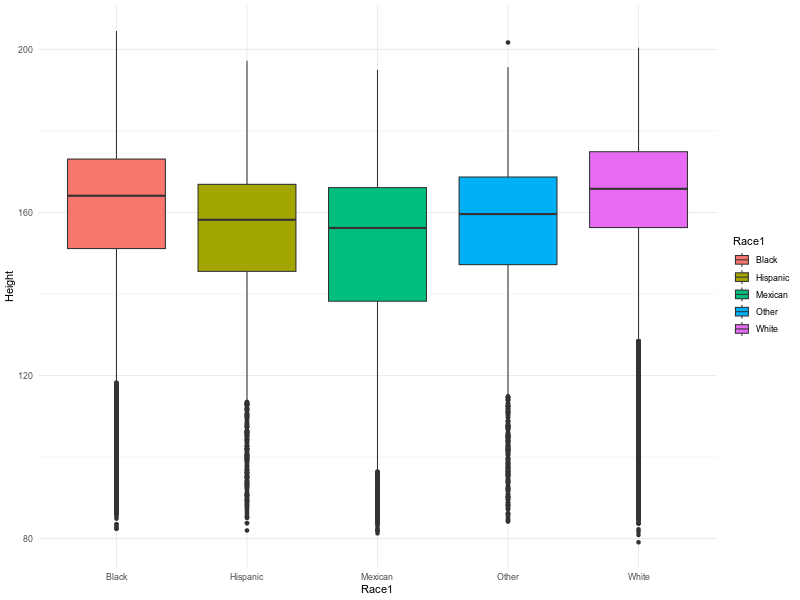

In [ ]:
#ggpot
nhanes |> 
  ggplot() + aes(x=Race1, y=Height, fill=Race1) + geom_boxplot() + theme_minimal()

In [ ]:
#Lubridate
# Date
# #Froamt YYYY-mm-dd 
Sys.Date()

[1] "2025-08-16"

In [22]:
date1 <- "January 17th 2023"
date2 <- "15-4-83"
date3 <- "08/13/22"

In [23]:
mdy(date1)

[1] "2023-01-17"

In [24]:
dmy(date2)

[1] "1983-04-15"

In [25]:
mdy(date3)

[1] "2022-08-13"

In [28]:
#parts of dates

mdy(date1) |> year()

[1] 2023

In [29]:
mdy(date1) |> month()

[1] 1

In [30]:
mdy(date1) |> day()

[1] 17

In [31]:
mdy(date1) |> week()

[1] 3

In [33]:
swearing_in = "January 20 2025"
today = Sys.Date()

In [36]:
today - swearing_in |> mdy()

Time difference of 208 days

In [ ]:
(today - swearing_in |> mdy()) |> as.numeric() / 7 #weeks

[1] 29.71429

In [ ]:
(today - swearing_in |> mdy()) |> as.numeric() / 30 #months

[1] "208y 0m 0d 0H 0M 0S"

In [44]:
(today - swearing_in |> mdy()) |> as.numeric() / 365.25 #years

[1] 0.569473

In [53]:
list(
  name = c('Lara', 'Sunday', 'Monday', 'Memunat'), 
  dob = c('12/12/1963', '7/3/85', '11/5/74', '8/12/90')
) |> as.data.frame() |> tibble() -> fake_data

In [56]:
fake_data |> 
  mutate(age = floor(as.numeric(Sys.Date() - dmy(dob))/365.25)) 

# A tibble: 4 × 3
  name    dob          age
  <chr>   <chr>      <dbl>
1 Lara    12/12/1963    61
2 Sunday  7/3/85        40
3 Monday  11/5/74       51
4 Memunat 8/12/90       34

In [57]:
#round does to nearest whole number
#ceiling does to to while number - rounds up
#floor does to bottom whole number - rounds down

In [64]:
#forcats
#fators - ordinal


nhanes$Race1 |> fct_infreq()

   [1] White    Other    Black    Black    Black    Mexican  White    White    Hispanic White   
  [11] Mexican  White    Other    White    White    Mexican  Hispanic Black    Mexican  Black   
  [21] White    Mexican  White    White    Mexican  Black    Mexican  Black    Mexican  White   
  [31] White    Mexican  White    White    Mexican  White    Mexican  Mexican  Mexican  Hispanic
  [41] White    White    Mexican  White    Black    Mexican  White    Black    White    White   
  [51] White    White    Black    White    White    Other    Black    White    White    White   
  [61] Mexican  White    Mexican  White    White    Mexican  Hispanic White    Hispanic Black   
  [71] White    White    Black    Black    Hispanic Mexican  Mexican  White    White    Black   
  [81] Mexican  Mexican  Mexican  Other    White    Mexican  White    Other    Mexican  White   
  [91] White    Mexican  White    White    Mexican  White    Other    Mexican  White    Black   
 [101] Hispanic Mexican  White

In [65]:

nhanes$Race1 |> fct_infreq() |> table()


   White    Black  Mexican    Other Hispanic 
    7393     4640     3739     2312     2209 

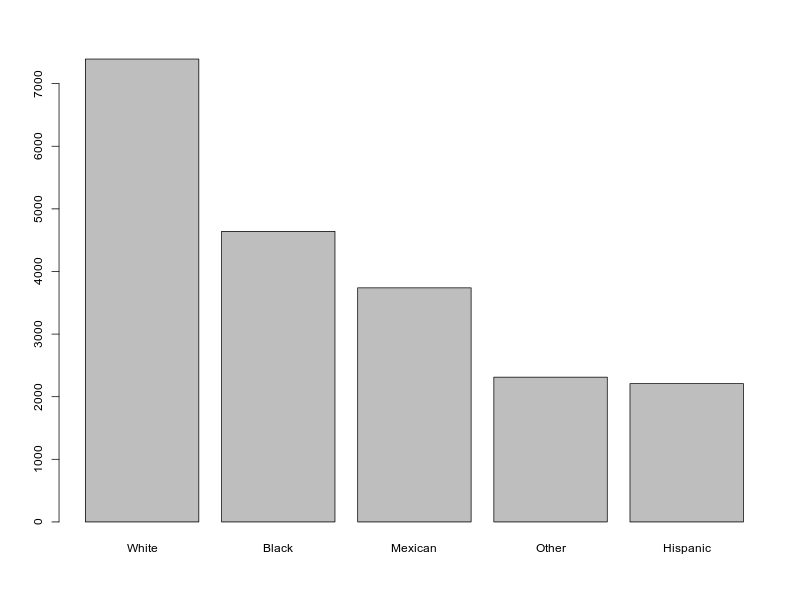

In [66]:
nhanes$Race1 |> fct_infreq() |> table() |> barplot()

In [67]:
nhanes$Race1 |> table()


   Black Hispanic  Mexican    Other    White 
    4640     2209     3739     2312     7393 

In [68]:
nhanes$Race1 |> fct_rev() |> table()


   White    Other  Mexican Hispanic    Black 
    7393     2312     3739     2209     4640 

In [70]:
nhanes$Race1 |> fct_infreq() |> table()


   White    Black  Mexican    Other Hispanic 
    7393     4640     3739     2312     2209 

In [71]:
nhanes$Race1 |> fct_infreq() |> fct_rev() |> table()


Hispanic    Other  Mexican    Black    White 
    2209     2312     3739     4640     7393 

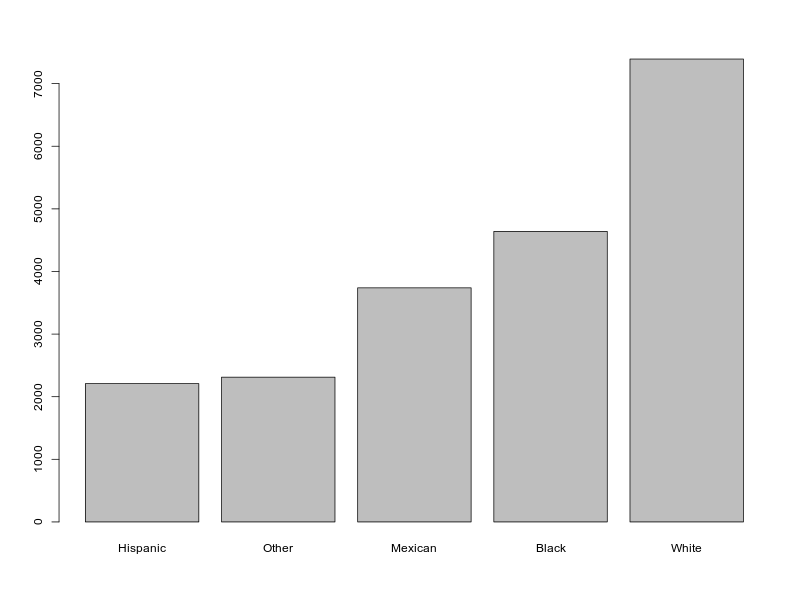

In [72]:
nhanes$Race1 |> fct_infreq() |> fct_rev() |> table() |> barplot()

In [75]:
nhanes$Race1 |> fct_relevel('Other', 'Mexican', 'White', 'Black', 'Hispanic') |> table()


   Other  Mexican    White    Black Hispanic 
    2312     3739     7393     4640     2209 

In [77]:
nhanes$Race1 |> table()


   Black Hispanic  Mexican    Other    White 
    4640     2209     3739     2312     7393 

In [82]:
nhanes$Race1 |> fct_recode('Asian'='Other') |> table()


   Black Hispanic  Mexican    Asian    White 
    4640     2209     3739     2312     7393 

In [83]:
nhanes$Race1 |> fct_recode('Asian'='Other', 'Hispanic'='Mexican') |> table()


   Black Hispanic    Asian    White 
    4640     5948     2312     7393 

In [100]:
nhanes |> 
  filter(Age >= 18) |> 
  select(Age, Sex=Gender, Race=Race1, Education, Weight, Height) |> 
  sample_n(100) -> adults

In [105]:
adults |> 
  mutate(Race = Race |> fct_recode('Hispanic'='Mexican')) |> 
  mutate(Education = Education |> fct_recode(
    'Senior Secondary' = 'High School', 
    'Junior Secondary' = '9 - 11th Grade', 
    'Undergraduate' = 'Some College', 
    'Graduate'  = 'College Grad', 
    'Primary School' = '8th Grade'
)) -> adults.2

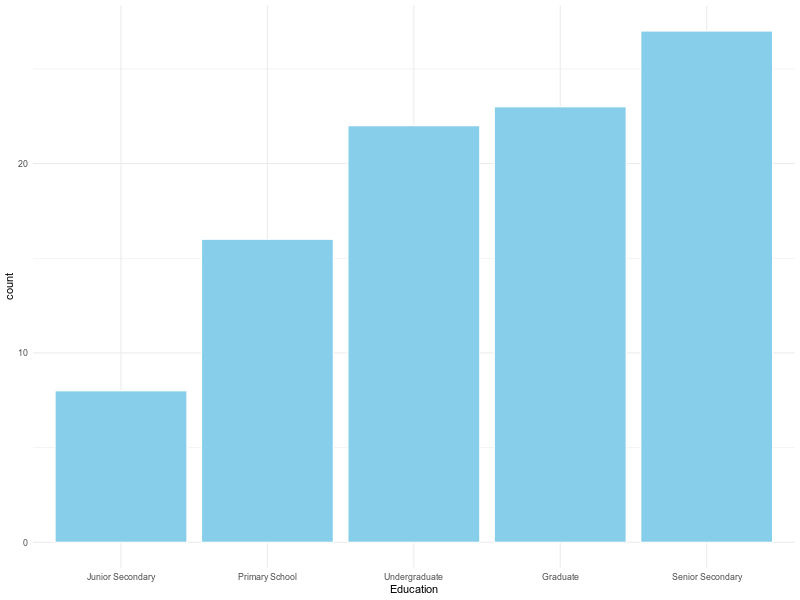

In [109]:
adults.2 |> 
  filter(!is.na(Education)) |> 
  #mutate(Education = Education |> fct_relevel('Primary School', 'Junior Secondary', 'Senior Secondary', 'Undergraduate', 'Graduate')) |> 
  mutate(Education = Education |> fct_infreq() |> fct_rev()) |> 
  ggplot() + aes(Education) + geom_bar(fill='skyblue', color='white') + theme_minimal() 

In [112]:
#purrr
adults.2 |> 
  mutate(BMI = Weight/(Height/100)^2)

# A tibble: 100 × 7
     Age Sex    Race     Education        Weight Height   BMI
   <dbl> <chr>  <fct>    <fct>             <dbl>  <dbl> <dbl>
 1    24 male   White    Senior Secondary   88.9   169   31.1
 2    55 female Other    Graduate           53.4   146.  25.2
 3    26 male   Hispanic Junior Secondary   79     180.  24.4
 4    24 male   White    Junior Secondary   63.3   171   21.6
 5    59 female White    Senior Secondary   84.2   164.  31.3
 6    35 female Black    Undergraduate      90.5   174.  30.0
 7    63 female Black    Senior Secondary   69.5   160.  27.0
 8    54 male   White    Undergraduate      91.1   171   31.2
 9    54 female Hispanic Senior Secondary  148     160.  58.0
10    43 male   Hispanic Undergraduate     125.    190.  34.7
# ℹ 90 more rows
# ℹ Use `print(n = ...)` to see more rows

In [118]:
#creating a user defined function

bmi_calculator = function(w, h){
  h_to_m = h/100
  h2 = h_to_m^2
  bmi = w/h2
  round(bmi, 2)
}

In [116]:
bmi_calculator(90.5, 174)

[1] 30

In [120]:
#purrr
#pmap_int
#pmap_char
#pmap_dbl
#pmap_lgl

adults.2 |> 
  mutate(BMI = pmap_dbl( list(Weight, Height), ~bmi_calculator(..1, ..2) ) )

# A tibble: 100 × 7
     Age Sex    Race     Education        Weight Height   BMI
   <dbl> <chr>  <fct>    <fct>             <dbl>  <dbl> <dbl>
 1    24 male   White    Senior Secondary   88.9   169   31.1
 2    55 female Other    Graduate           53.4   146.  25.2
 3    26 male   Hispanic Junior Secondary   79     180.  24.4
 4    24 male   White    Junior Secondary   63.3   171   21.6
 5    59 female White    Senior Secondary   84.2   164.  31.3
 6    35 female Black    Undergraduate      90.5   174.  30  
 7    63 female Black    Senior Secondary   69.5   160.  27.0
 8    54 male   White    Undergraduate      91.1   171   31.2
 9    54 female Hispanic Senior Secondary  148     160.  58.0
10    43 male   Hispanic Undergraduate     125.    190.  34.7
# ℹ 90 more rows
# ℹ Use `print(n = ...)` to see more rows

>select, 
filter, 
mutuate, 
ifelse, 
case_when
purrr
lubridate,
separate, 
unite


>aggregate analysis
group_by
summarise


>pivot_longer, 
pivot_wider


>window functions
sum, 
n, 
p, 
row_number, 
min, 
max, 
rank, 
first_value, 
last_value, 
lead, 
lag
